# PRACTICE EMAIL SPAM CLASSIFICATION.

1. Dataset Description

The dataset used in this project was obtained from Kaggle, one of the most popular platforms for Machine Learning research and practice. The dataset contains a collection of emails that have been pre-labeled into two categories: Spam and Ham, making it suitable for a text classification task.

Where:

- Spam: Unwanted emails such as advertisements, marketing messages, scams, or other unsolicited content.
- Ham: Legitimate emails that contain normal communication and information exchange between the sender and the recipient.

Each record in the dataset consists of the email text and its corresponding class label. This allows Machine Learning models to learn the characteristics of each email category and automatically classify new incoming emails.

2. Problem Context and Objective

In real-world scenarios, an individual user may receive dozens or even hundreds of emails every day. Manually reading and sorting each email can be time-consuming and may result in overlooking important messages or accidentally opening fraudulent emails.

Therefore, a Spam/Ham email classification system is developed to:

- Automatically detect spam emails before they are read by the user.
- Reduce the time required to manage and organize email inboxes.
- Minimize the risk of fraud caused by phishing emails or malicious links.
- Improve the overall email experience for individual users.

In this project, email content is processed using text preprocessing techniques and transformed into numerical representations for Machine Learning model training. The models then learn the differences between Spam and Ham emails and use this knowledge to accurately predict the category of new emails.

# Project Workflow

## 1. Exploratory Data Analysis (EDA)

* Dataset Overview
* Missing Value Analysis
* Duplicate Data Detection
* Spam/Ham Class Distribution
* Email Length Analysis
* Word Count Analysis
* Special Character Analysis
* Most Frequent Words Analysis

## 2. Data Preprocessing

* Text Normalization
* Removal of HTML Tags, URLs, Punctuation, Special Characters, and Stopwords
* Comparison Before and After Preprocessing

## 3. Feature Engineering

The following handcrafted features are extracted from each email:

* Text Length
* Word Count
* Exclamation Count
* Dollar Count
* Uppercase Ratio
* URL Count

In addition, feature distributions are visualized and compared to evaluate their effectiveness in distinguishing Spam and Ham emails.

## 4. Feature Extraction

* TF-IDF Vectorization

The preprocessed email texts are transformed into numerical feature vectors using the Term Frequency–Inverse Document Frequency (TF-IDF) technique.

## 5. Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

## 6. Model Training and Evaluation

Three Machine Learning models are implemented and trained:

* Logistic Regression
* Multinomial Naive Bayes
* Linear Support Vector Machine (SVM)

Each model is evaluated using the following metrics:

* Accuracy
* Precision
* Recall
* F1-Score
* Confusion Matrix

The evaluation results are analyzed to determine the strengths and weaknesses of each model.

## 7. New Email Prediction

The trained models are used to classify previously unseen emails as either Spam or Ham.

## 8. Results Summary

A summary of model performance is provided, including:

* Accuracy Comparison
* Precision Comparison
* Recall Comparison
* F1-Score Comparison
* Analysis of False Positives and False Negatives
* Discussion of the most suitable model for personal email spam filtering

## 9. Model Saving and Deployment

* Save trained models and TF-IDF vectorizer
* Load saved models for future predictions
* Build a simple deployment interface for real-world spam email classification


In [1]:
# =========================
# 0. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import re
import string
import pickle
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import wordcloud as WordCloud
from wordcloud import WordCloud
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

#model base build from scratch
from models.logictisregression import LogisticRegressionM
from models.naive_bayes import MultinomialNaiveBayes
from models.svm import LinearSVM
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score, classification_report
from utils.metrics import evaluate_from_cm

import joblib

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hovan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("data/email_spam.csv", encoding="latin1")

df_EDA = df.copy()

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Exploratory Data Analysis (EDA)

## Dataset Overview


In [3]:
print("Kích thước dữ liệu:", df_EDA.shape)
df_EDA.info()

Kích thước dữ liệu: (5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df_EDA.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


total rows: 5572 , total columns: 5


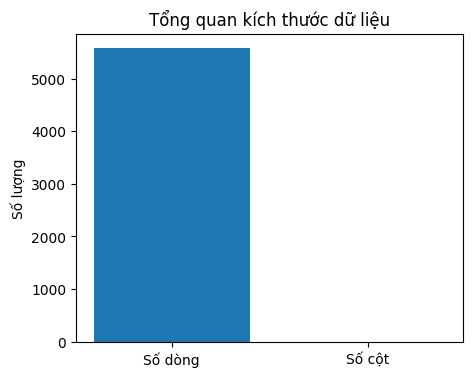

In [5]:
print("total rows:",df_EDA.shape[0], ", total columns:",df_EDA.shape[1])
plt.figure(figsize=(5, 4))
plt.bar(["Số dòng", "Số cột"], [df_EDA.shape[0], df_EDA.shape[1]])
plt.title("Tổng quan kích thước dữ liệu")
plt.ylabel("Số lượng")
plt.show()

## Missing value and duplicate 

In [6]:
missing_values = df_EDA.isnull().sum()
missing_values

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

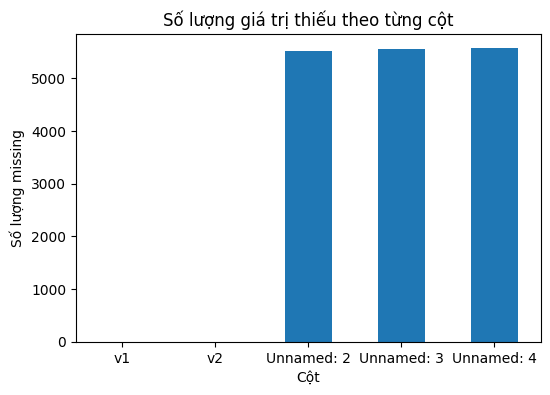

In [7]:
plt.figure(figsize=(6, 4))
missing_values.plot(kind="bar")
plt.title("Số lượng giá trị thiếu theo từng cột")
plt.xlabel("Cột")
plt.ylabel("Số lượng missing")
plt.xticks(rotation=0)
plt.show()

In [8]:
duplicate_count = df_EDA.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)

Số dòng trùng lặp: 403


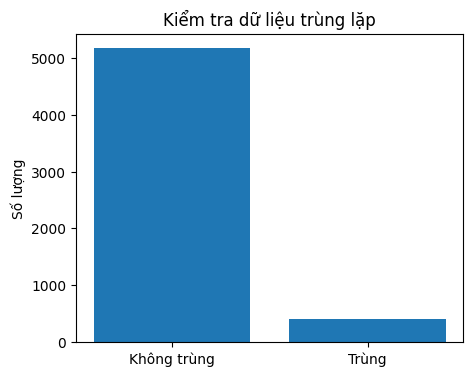

In [9]:
plt.figure(figsize=(5, 4))
plt.bar(["Không trùng", "Trùng"], [len(df_EDA) - duplicate_count, duplicate_count])
plt.title("Kiểm tra dữ liệu trùng lặp")
plt.ylabel("Số lượng")
plt.show()

In [10]:
df_EDA = df_EDA.drop_duplicates()
df = df.drop_duplicates()
print("Kích thước sau khi xóa trùng:", df_EDA.shape)

Kích thước sau khi xóa trùng: (5169, 5)


## label distribution

In [11]:
label_counts = df_EDA["v1"].value_counts()
label_counts

v1
ham     4516
spam     653
Name: count, dtype: int64

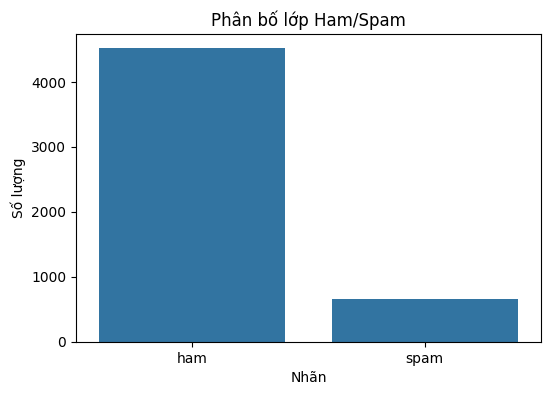

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_EDA, x="v1")
plt.title("Phân bố lớp Ham/Spam")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng")
plt.show()

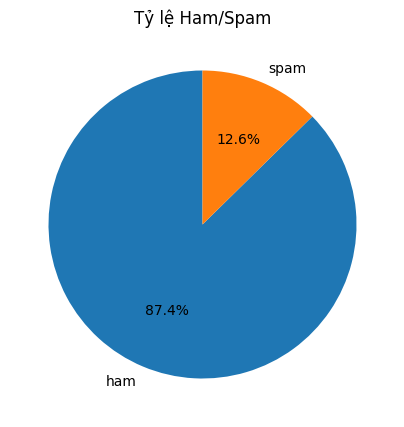

In [13]:
plt.figure(figsize=(5, 5))
plt.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Tỷ lệ Ham/Spam")
plt.show()

## Email length Analysis

In [14]:
df_EDA["text_length"] = df_EDA["v2"].apply(len)

df_EDA.groupby("v1")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
v1,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


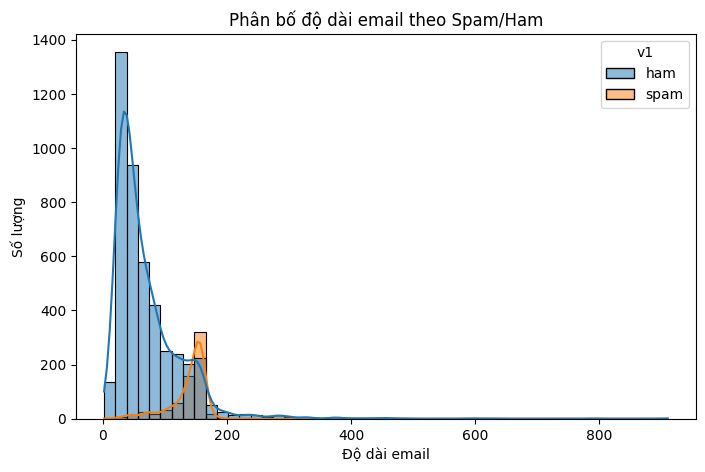

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_EDA, x="text_length", hue="v1", bins=50, kde=True)
plt.title("Phân bố độ dài email theo Spam/Ham")
plt.xlabel("Độ dài email")
plt.ylabel("Số lượng")
plt.show()

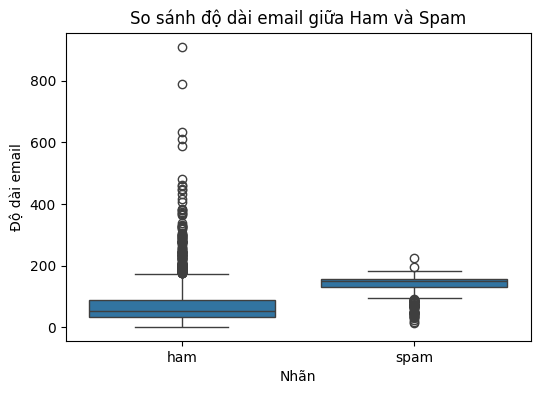

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_EDA, x="v1", y="text_length")
plt.title("So sánh độ dài email giữa Ham và Spam")
plt.xlabel("Nhãn")
plt.ylabel("Độ dài email")
plt.show()

## Word Count Analysis

In [17]:
df_EDA["word_count"] = df_EDA["v2"].apply(lambda x: len(str(x).split()))

df_EDA.groupby("v1")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
v1,,,,,,,,
ham,4516.0,14.134632,11.116240,1.0,7.0,11.0,18.0,171.0
spam,653.0,23.681470,5.967672,2.0,22.0,25.0,28.0,35.0


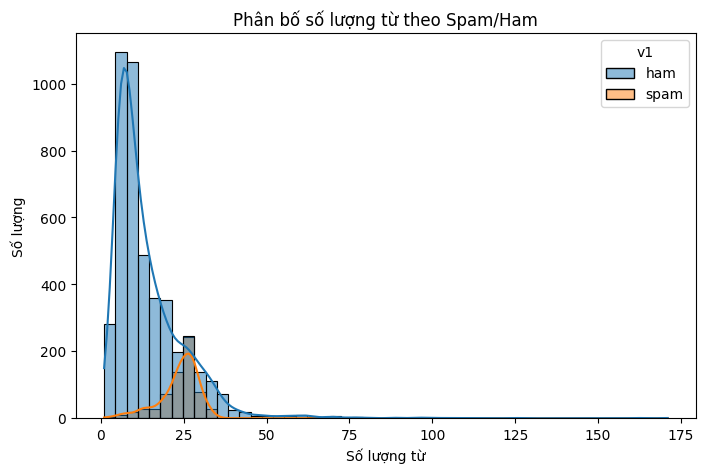

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_EDA, x="word_count", hue="v1", bins=50, kde=True)
plt.title("Phân bố số lượng từ theo Spam/Ham")
plt.xlabel("Số lượng từ")
plt.ylabel("Số lượng")
plt.show()

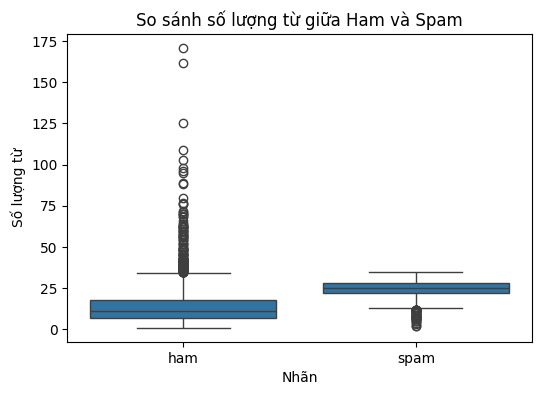

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_EDA, x="v1", y="word_count")
plt.title("So sánh số lượng từ giữa Ham và Spam")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng từ")
plt.show()

## special characters analysis

In [20]:
df_EDA["exclamation_count"] = df_EDA["v2"].apply(lambda x: str(x).count("!"))
df_EDA["dollar_count"] = df_EDA["v2"].apply(lambda x: str(x).count("$"))
df_EDA["question_count"] = df_EDA["v2"].apply(lambda x: str(x).count("?"))

special_summary = df_EDA.groupby("v1")[[
    "exclamation_count",
    "dollar_count",
    "question_count"
]].mean()

special_summary

,exclamation_count,dollar_count,question_count
v1,,,
ham,0.174712,0.004207,0.292958
spam,0.693721,0.006126,0.243492


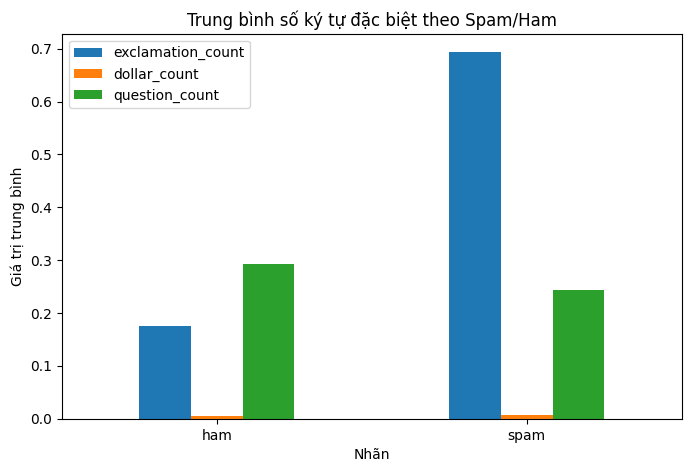

In [21]:
special_summary.plot(kind="bar", figsize=(8, 5))
plt.title("Trung bình số ký tự đặc biệt theo Spam/Ham")
plt.xlabel("Nhãn")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=0)
plt.show()

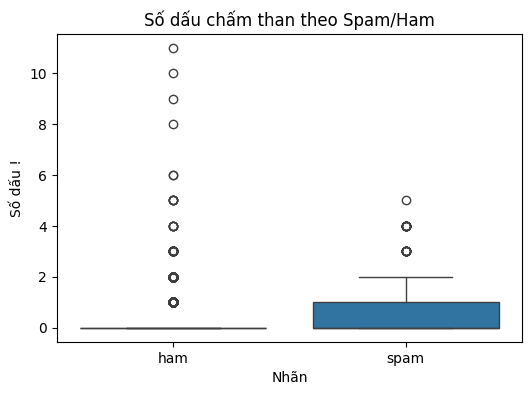

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_EDA, x="v1", y="exclamation_count")
plt.title("Số dấu chấm than theo Spam/Ham")
plt.xlabel("Nhãn")
plt.ylabel("Số dấu !")
plt.show()

## Analyze the most frequently appearing words.

In [23]:
ham_words = " ".join(df_EDA[df_EDA["v1"] == "ham"]["v2"]).lower().split()
spam_words = " ".join(df_EDA[df_EDA["v1"] == "spam"]["v2"]).lower().split()

ham_common = Counter(ham_words).most_common(20)
spam_common = Counter(spam_words).most_common(20)

ham_common_df = pd.DataFrame(ham_common, columns=["word", "count"])
spam_common_df = pd.DataFrame(spam_common, columns=["word", "count"])

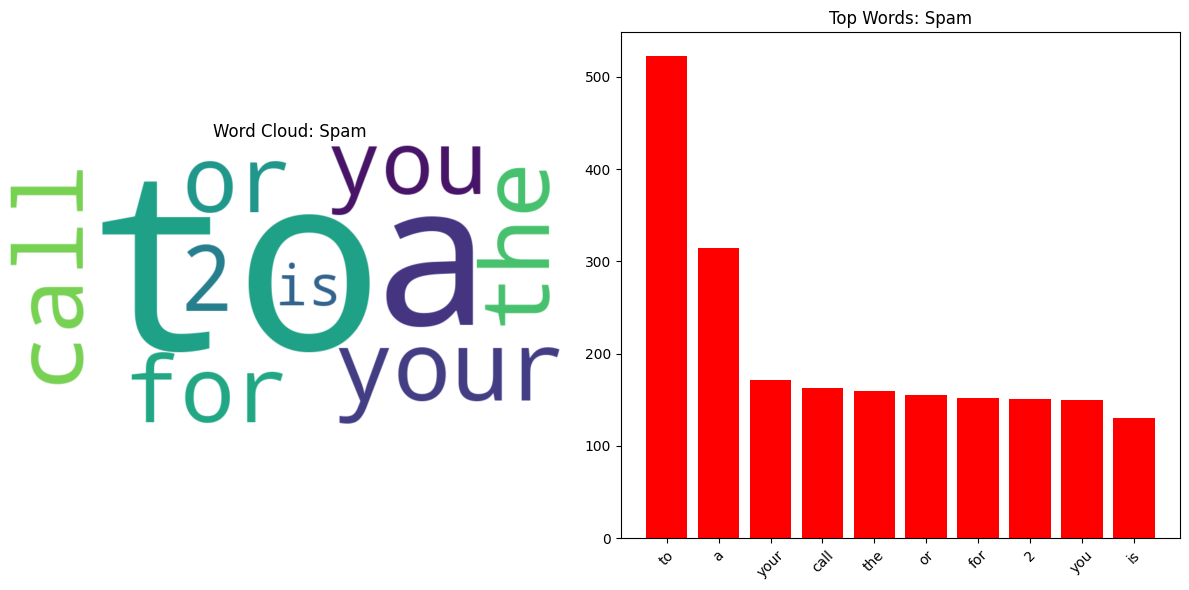

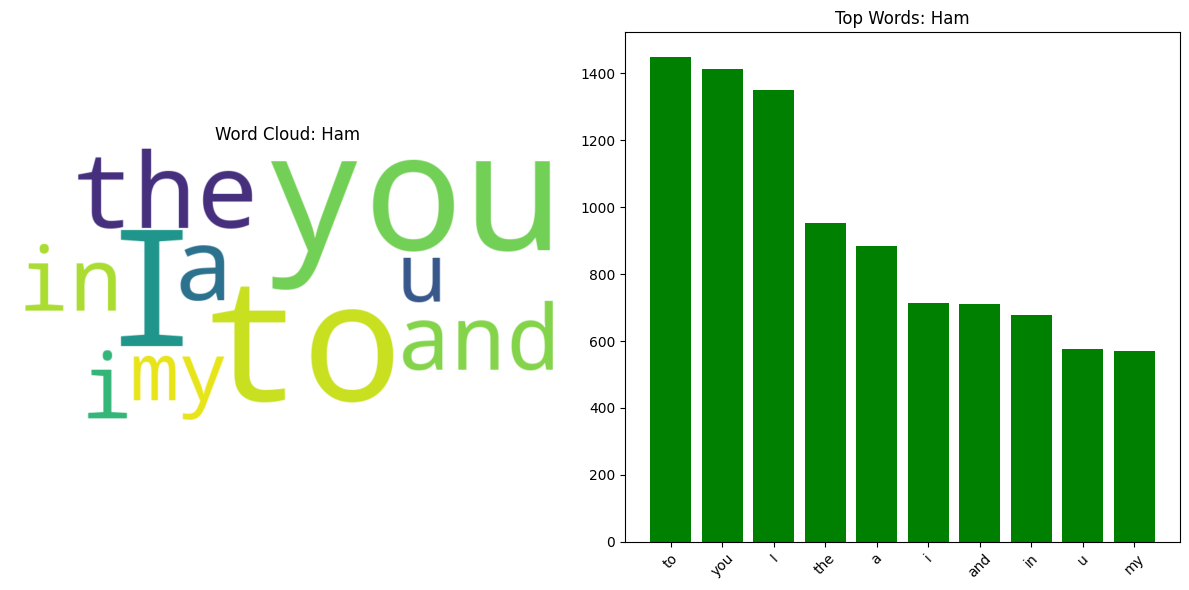

In [24]:

def plot_word_analysis(emails_series, title_suffix, color='orange'):
    # Tokenize and count
    words = ' '.join(emails_series).split()
    word_counts = Counter(words)
    most_common = word_counts.most_common(10)
    
    # Extract data for plotting
    words_list, counts = zip(*most_common)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    # Word Cloud
    plt.subplot(1, 2, 1)
    # Generate from frequencies uses a dictionary
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(most_common))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Word Cloud: {title_suffix}')
    plt.axis('off')
    
    # Bar Chart
    plt.subplot(1, 2, 2)
    plt.bar(words_list, counts, color=color)
    plt.title(f'Top Words: {title_suffix}')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_word_analysis(df_EDA[df_EDA['v1'] == "spam"]['v2'], "Spam", color='red')
plot_word_analysis(df_EDA[df_EDA['v1'] == "ham"]['v2'],  "Ham",  color='green')

# Preprocessing

## standardize text


In [25]:
df.rename(
    columns={
        "v1": "label",
        "v2": "message"
    },
    inplace=True
)

df.head()

df.drop(
    columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"],
    inplace=True,
    errors="ignore"
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Remove HTML tags, URLs, punctuation, and special characters, Stopwords

In [27]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()                         

    text = re.sub(r"<.*?>", " ", text)             

    text = re.sub(r"http\S+|www\S+", " ", text)     

    text = re.sub(r"[^a-zA-Z\s]", " ", text)        

    words = text.split()

    words = [word for word in words
             if word not in stop_words]             

    return " ".join(words)

df["message_clean"] = df["message"].apply(clean_text)

In [28]:
df

,label,message,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,nd time tried contact u u pound prize claim ea...
5568,0,Will Ì_ b going to esplanade fr home?,b going esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood suggestions
5570,0,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...


## Compare before and after preprocess

In [29]:
comparison_df = df[["message", "message_clean"]]

comparison_df.head(10)

,message,message_clean
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


In [30]:
for i in range(3):
    print("Before:")
    print(df["message"].iloc[i])

    print("\nAfter:")
    print(df["message_clean"].iloc[i])

    print("-" * 80)

Before:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

After:
go jurong point crazy available bugis n great world la e buffet cine got amore wat
--------------------------------------------------------------------------------
Before:
Ok lar... Joking wif u oni...

After:
ok lar joking wif u oni
--------------------------------------------------------------------------------
Before:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

After:
free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply
--------------------------------------------------------------------------------


# Feature Engineering.

In [31]:
def uppercase_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)


def url_count(text):
    return len(re.findall(r"http\S+|www\S+", str(text)))

In [32]:
df["message_length"] = df["message"].apply(len)

df["message_word_count"] = df["message"].apply(
    lambda x: len(str(x).split())
)

df["exclamation_count"] = df["message"].apply(
    lambda x: str(x).count("!")
)

df["dollar_count"] = df["message"].apply(
    lambda x: str(x).count("$")
)

df["uppercase_ratio"] = df["message"].apply(uppercase_ratio)

df["url_count"] = df["message"].apply(url_count)

In [33]:


feature_cols = [
    "message_length",
    "message_word_count",
    "exclamation_count",
    "dollar_count",
    "uppercase_ratio",
    "url_count"
]

scaled_df = df.copy()

scaler = MinMaxScaler()

scaled_df[feature_cols] = scaler.fit_transform(
    scaled_df[feature_cols]
)

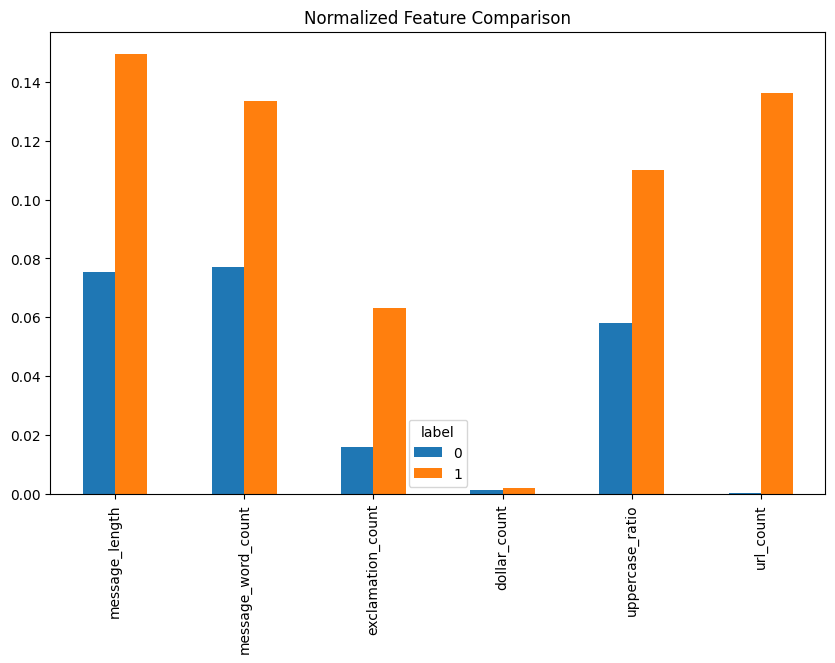

In [34]:
feature_summary = scaled_df.groupby("label")[
    feature_cols
].mean()

feature_summary.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Normalized Feature Comparison")
plt.show()

# Feature Extraction

## Transform data

In [35]:
X_text = df["message_clean"]
y = df["label"]

tfidf = TfidfVectorizer(
    max_features=3000
)

X_tfidf = tfidf.fit_transform(X_text)

In [36]:
print(X_tfidf.shape)  

(5169, 3000)


In [37]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aah' 'aathi' 'abi' 'ability' 'abiola' 'abj' 'able' 'abt' 'abta' 'aburo'
 'ac' 'academic' 'acc' 'accept' 'access' 'accident' 'accidentally'
 'accordingly' 'account' 'ache' 'acl' 'across' 'action' 'activate'
 'actually' 'ad' 'add' 'added' 'addie' 'address' 'admirer' 'adore' 'adult'
 'advance' 'advice' 'ae' 'affairs' 'afraid' 'aft' 'afternoon' 'aftr' 'age'
 'ages' 'ago' 'ah' 'aha' 'ahead' 'ahmad' 'aight' 'aint']


In [38]:
word_scores = X_tfidf.sum(axis=0).A1

tfidf_df = pd.DataFrame({
    "word": feature_names,
    "score": word_scores
})

tfidf_df = tfidf_df.sort_values(
    by="score",
    ascending=False
)

In [39]:
top_words = tfidf_df.head(20)

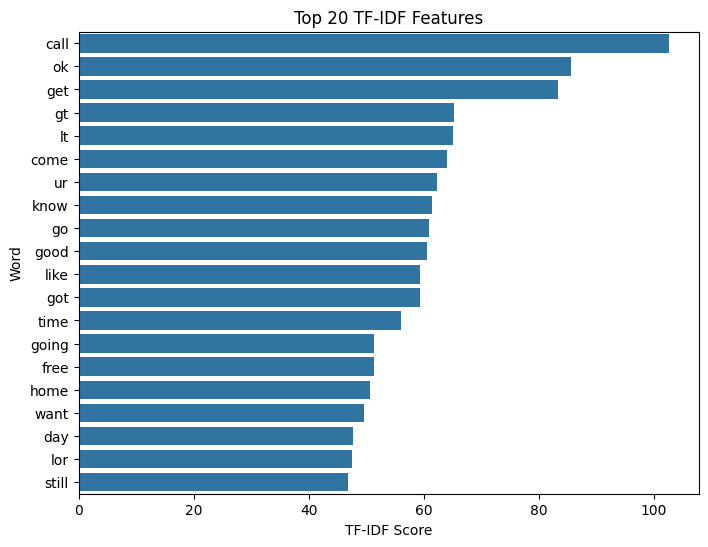

In [40]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=top_words,
    x="score",
    y="word"
)

plt.title("Top 20 TF-IDF Features")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")

plt.show()

# Train / test split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [42]:
train_dist = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percent": y_train.value_counts(normalize=True) * 100
})

test_dist = pd.DataFrame({
    "Count": y_test.value_counts(),
    "Percent": y_test.value_counts(normalize=True) * 100
})

print("TRAIN SET")
print(train_dist)

print("\nTEST SET")
print(test_dist)

TRAIN SET
       Count    Percent
label                  
0       3161  87.368712
1        457  12.631288

TEST SET
       Count    Percent
label                  
0       1355  87.362992
1        196  12.637008


C:\Users\hovan\AppData\Local\Temp\ipykernel_2292\1704482217.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Ham", "Spam"])
C:\Users\hovan\AppData\Local\Temp\ipykernel_2292\1704482217.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Ham", "Spam"])


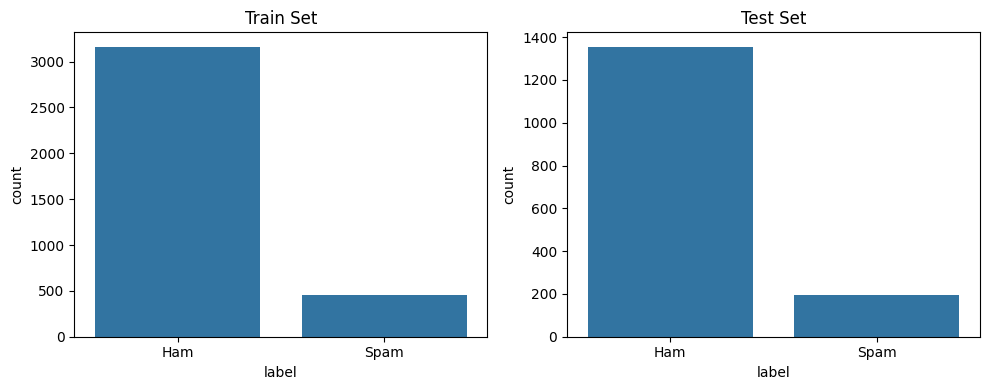

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Train Set")
axes[0].set_xticklabels(["Ham", "Spam"])

sns.countplot(
    x=y_test,
    ax=axes[1]
)

axes[1].set_title("Test Set")
axes[1].set_xticklabels(["Ham", "Spam"])

plt.tight_layout()
plt.show()

# Model Training

## model logistic

## Logistic Regression

In [44]:
lr_model = LogisticRegressionM(learning_rate=3, n_iters=5000)

X_train_lr = X_train.toarray()
X_test_lr = X_test.toarray()

y_train_lr = np.array(y_train)
y_test_lr = np.array(y_test)

lr_model.fit(X_train_lr, y_train_lr)

epoch = 0/5000: loss = 0.6931
epoch = 500/5000: loss = 0.1418
epoch = 1000/5000: loss = 0.0994
epoch = 1500/5000: loss = 0.0794
epoch = 2000/5000: loss = 0.0670
epoch = 2500/5000: loss = 0.0583
epoch = 3000/5000: loss = 0.0516
epoch = 3500/5000: loss = 0.0464
epoch = 4000/5000: loss = 0.0421
epoch = 4500/5000: loss = 0.0385


(array([-0.18389303, -0.16703666, -0.16157849, ...,  0.89998241,
        -0.05833689,  0.56132302]),
 -3.881803373617478)

In [45]:
print("=== Logistic Regression – Classification Report ===")
lr_model.classification_Report(X_test_lr, y_test_lr)

=== Logistic Regression – Classification Report ===

                 precision     recall   f1-score    support

              0       0.99       0.99       0.99       1355
              1       0.92       0.90       0.91        196
       accuracy                             0.98       1551
      macro avg       0.95       0.94       0.95    1551.00


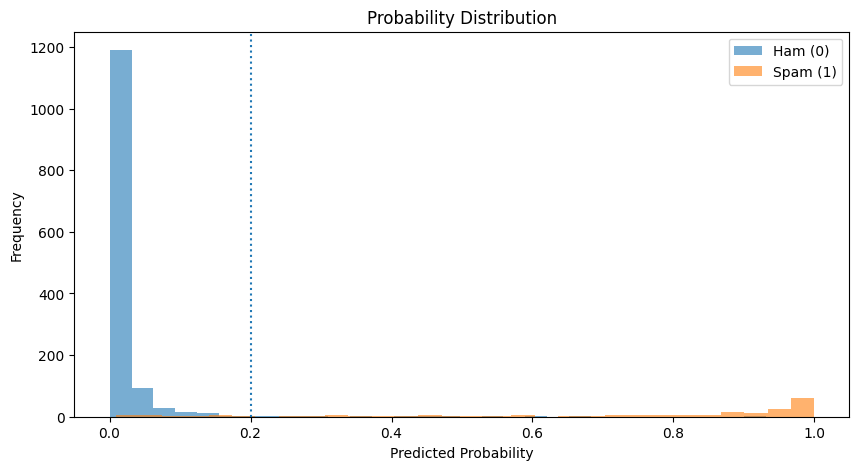

In [46]:
y_prob = lr_model.predict_proba(X_test_lr)

spam_probs = y_prob[y_test_lr == 1]
ham_probs = y_prob[y_test_lr == 0]

plt.figure(figsize=(10,5))

plt.hist(
    ham_probs,
    bins=30,
    alpha=0.6,
    label="Ham (0)"
)

plt.hist(
    spam_probs,
    bins=30,
    alpha=0.6,
    label="Spam (1)"
)

plt.axvline(
    x=0.2,
    linestyle=":"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution")
plt.legend()
plt.show()

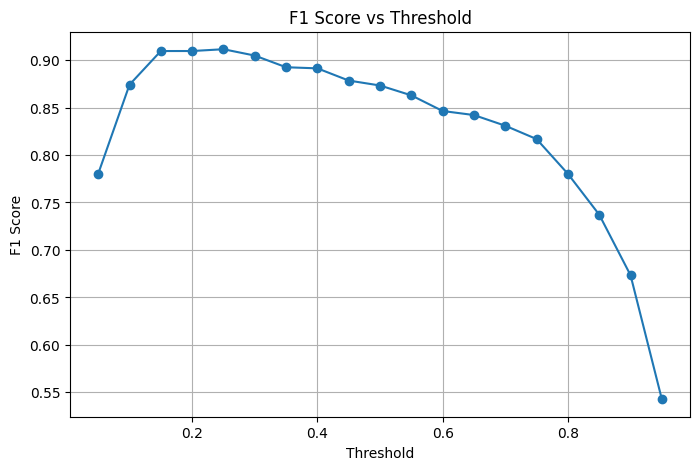

In [47]:

thresholds = np.arange(0.05, 1.0, 0.05)

f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    f1 = f1_score(y_test_lr, y_pred)

    f1_scores.append(f1)

plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores, marker="o")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")

plt.grid(True)

plt.show()

In [48]:
y_pred_log = lr_model.predict(
    X_test_lr,
)

cm_lr = confusion_matrix(
    y_test_lr,
    y_pred_log
)

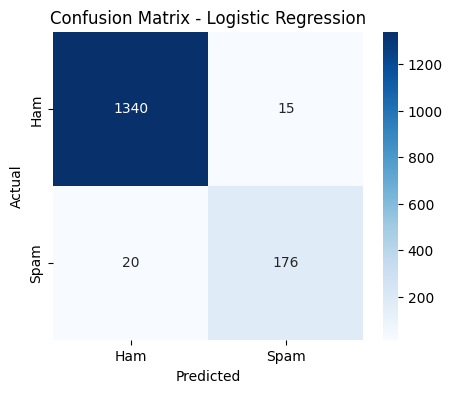

In [49]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Naive Bayes

In [50]:
# Naive Bayes nhận count/TF-IDF dense array
nb_model = MultinomialNaiveBayes(alpha=0.1)

X_train_arr = X_train.toarray()
X_test_arr = X_test.toarray()

y_train_arr = y_train.values
y_test_arr = y_test.values

In [51]:
nb_model.fit(X_train_arr, y_train_arr)

In [52]:
print("=== Naive Bayes – Classification Report ===")
y_pred_nb = nb_model.predict(X_test_arr)
print(classification_report(y_test_arr, y_pred_nb))

=== Naive Bayes – Classification Report ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1355
           1       0.98      0.89      0.93       196

    accuracy                           0.98      1551
   macro avg       0.98      0.94      0.96      1551
weighted avg       0.98      0.98      0.98      1551



In [53]:
cm_nb = confusion_matrix(
    y_test_arr,
    y_pred_nb
)

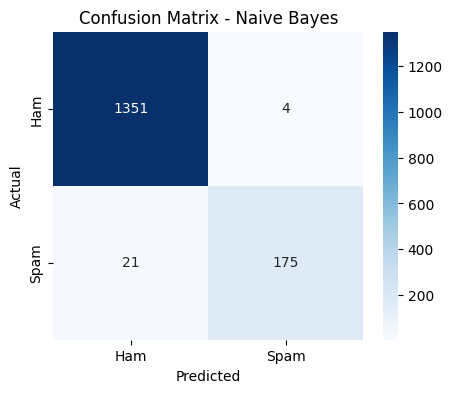

In [54]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# SVM

In [55]:
X_train_svm = X_train.toarray()
X_test_svm = X_test.toarray()

y_train_svm = y_train.values
y_test_svm = y_test.values

In [56]:
svm_model = LinearSVM(
    learning_rate=1,
    lambda_param=0.00005,
    epochs=5000,
    print_every=500
)

svm_model.fit(X_train_svm, y_train_svm)

Epoch 500/5000 - Hinge Loss: 0.1264
Epoch 1000/5000 - Hinge Loss: 0.0906
Epoch 1500/5000 - Hinge Loss: 0.0733
Epoch 2000/5000 - Hinge Loss: 0.0627
Epoch 2500/5000 - Hinge Loss: 0.0559
Epoch 3000/5000 - Hinge Loss: 0.0505
Epoch 3500/5000 - Hinge Loss: 0.0464
Epoch 4000/5000 - Hinge Loss: 0.0431
Epoch 4500/5000 - Hinge Loss: 0.0407
Epoch 5000/5000 - Hinge Loss: 0.0384


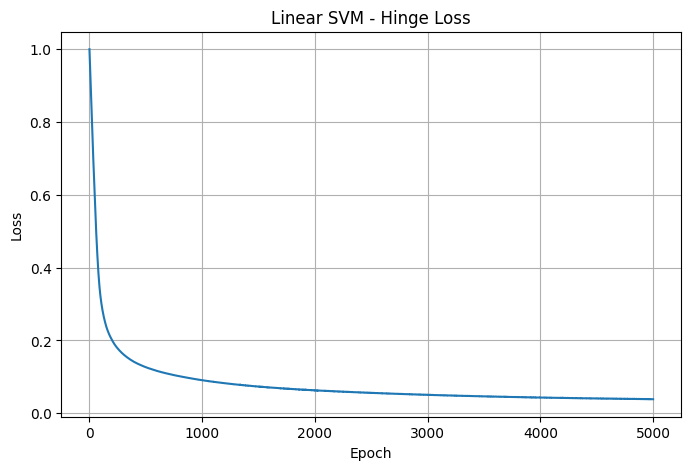

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(svm_model.losses)

plt.title("Linear SVM - Hinge Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [58]:
scores = svm_model.decision_function(X_test_svm)

thresholds = np.arange(
    scores.min(),
    scores.max(),
    0.05
)

threshold_results = []

for threshold in thresholds:
    y_pred_temp = np.where(scores >= threshold, 1, 0)

    p = precision_score(y_test_svm, y_pred_temp, pos_label=1, zero_division=0)
    r = recall_score(y_test_svm, y_pred_temp, pos_label=1, zero_division=0)
    f1 = f1_score(y_test_svm, y_pred_temp, pos_label=1, zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "precision": p,
        "recall": r,
        "f1_score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
print(best_row)

Best threshold: 0.00615622942698657
threshold    0.006156
precision    0.935135
recall       0.882653
f1_score     0.908136
Name: 60, dtype: float64


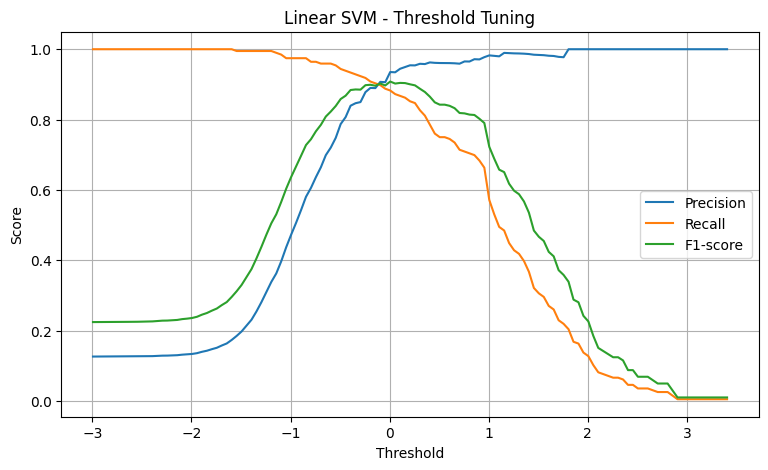

In [59]:
plt.figure(figsize=(9, 5))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1-score")

plt.title("Linear SVM - Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.show()

In [60]:
y_pred_svm = svm_model.predict(
    X_test_svm,
    threshold=best_threshold
)

classification_report(
    y_test_svm,
    y_pred_svm
)

cm_svm = confusion_matrix(
    y_test_svm,
    y_pred_svm
)


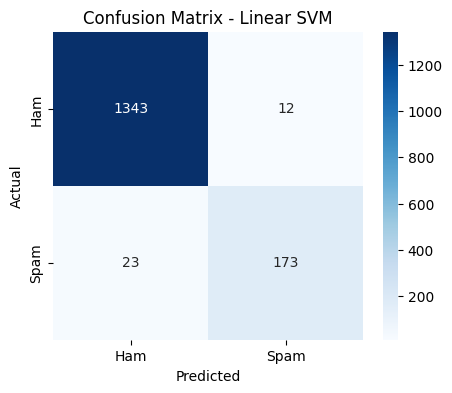

In [61]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
test_emails = [
    # Spam
    "Congratulations! You won a free gift card. Claim your prize now.",
    "Win $500 today. Click here to receive your cash reward.",
    "Limited time offer get 90%!!! discount if you buy now.",
    "You have been selected for a free lottery prize.",
    "Urgent! Your account will be closed unless you verify now.",

    # Ham
    "Hi, are we still meeting for lunch tomorrow?",
    "Please send me the homework file when you finish it.",
    "Your appointment is confirmed for Monday at 10 AM.",
    "Can you call me when you get home?",
    "Thanks for your message. I will reply later."
]

true_labels = np.array([
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0
])

clean_emails = []

clean_emails = [clean_text(email) for email in test_emails]

X_new = tfidf.transform(clean_emails).toarray()

true_labels = np.array(true_labels)

In [63]:
y_pred_log = lr_model.predict(
    X_new,
)

y_pred_nb = nb_model.predict(X_new)

y_pred_svm = svm_model.predict(
    X_new,
    threshold=best_threshold
)

In [64]:
result_df = pd.DataFrame({
    "Email": test_emails,
    "Actual": true_labels,
    "Logistic": y_pred_log,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm
})

result_df["Actual"] = result_df["Actual"].map({0: "Ham", 1: "Spam"})
result_df["Logistic"] = result_df["Logistic"].map({0: "Ham", 1: "Spam"})
result_df["Naive Bayes"] = result_df["Naive Bayes"].map({0: "Ham", 1: "Spam"})
result_df["SVM"] = result_df["SVM"].map({0: "Ham", 1: "Spam"})

result_df

,Email,Actual,Logistic,Naive Bayes,SVM
0,Congratulations! You won a free gift card. Cla...,Spam,Spam,Spam,Spam
1,Win $500 today. Click here to receive your cas...,Spam,Spam,Spam,Spam
2,Limited time offer get 90%!!! discount if you ...,Spam,Ham,Ham,Ham
3,You have been selected for a free lottery prize.,Spam,Spam,Spam,Spam
4,Urgent! Your account will be closed unless you...,Spam,Spam,Spam,Ham
5,"Hi, are we still meeting for lunch tomorrow?",Ham,Ham,Ham,Ham
6,Please send me the homework file when you fini...,Ham,Ham,Ham,Ham
7,Your appointment is confirmed for Monday at 10...,Ham,Ham,Ham,Ham
8,Can you call me when you get home?,Ham,Ham,Ham,Ham
9,Thanks for your message. I will reply later.,Ham,Spam,Ham,Ham


In [65]:
print("Logistic Regression")
print(classification_report(true_labels, y_pred_log))

print("Naive Bayes")
print(classification_report(true_labels, y_pred_nb))

print("Linear SVM")
print(classification_report(true_labels, y_pred_svm))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

Naive Bayes
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10

Linear SVM
              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.

In [66]:
summary_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Linear SVM"],
    "Accuracy": [
        accuracy_score(true_labels, y_pred_log),
        accuracy_score(true_labels, y_pred_nb),
        accuracy_score(true_labels, y_pred_svm)
    ]
})

summary_df

,Model,Accuracy
0,Logistic Regression,0.8
1,Naive Bayes,0.9
2,Linear SVM,0.8


# Sumary

In [67]:
#logictis
cm_log = np.array([
    [1340, 15],
    [20, 176]
])

log_result = evaluate_from_cm(
    cm_log,
    "Logistic Regression"
)

#naive_bayes
cm_nb = np.array([
    [1351, 4],
    [21, 175]
])

nb_result = evaluate_from_cm(
    cm_nb,
    "Naive Bayes"
)

#SVM
cm_svm = np.array([
    [1343, 12],
    [23, 173]
])

svm_result = evaluate_from_cm(
    cm_svm,
    "Linear SVM"
)


===== Logistic Regression =====
TN : 1340
FP : 15
FN : 20
TP : 176

Accuracy  : 0.9774
Precision : 0.9215
Recall    : 0.8980
F1-score  : 0.9096
TPR       : 0.8980
FPR       : 0.0111

===== Naive Bayes =====
TN : 1351
FP : 4
FN : 21
TP : 175

Accuracy  : 0.9839
Precision : 0.9777
Recall    : 0.8929
F1-score  : 0.9333
TPR       : 0.8929
FPR       : 0.0030

===== Linear SVM =====
TN : 1343
FP : 12
FN : 23
TP : 173

Accuracy  : 0.9774
Precision : 0.9351
Recall    : 0.8827
F1-score  : 0.9081
TPR       : 0.8827
FPR       : 0.0089


In [68]:
summary_df = pd.DataFrame([
    log_result,
    nb_result,
    svm_result
])

summary_df

,Model,Accuracy,Precision,Recall,F1,TPR,FPR,FP,FN
0,Logistic Regression,0.977434,0.921466,0.897959,0.909561,0.897959,0.011070,15,20
1,Naive Bayes,0.983881,0.977654,0.892857,0.933333,0.892857,0.002952,4,21
2,Linear SVM,0.977434,0.935135,0.882653,0.908136,0.882653,0.008856,12,23


### Deploy

In [69]:
# Lưu mô hình đã huấn luyện
joblib.dump(lr_model, "phanloaiemail.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(nb_model,    "naive_bayes_model.pkl")
print("Mô hình đã được lưu!")

Mô hình đã được lưu!


In [70]:
!ngrok config add-authtoken "3EaTBGrhOhc85JWX0GIBusHAPEp_VwiHhXGFK51FFksUtMka"

Authtoken saved to configuration file: C:\Users\hovan\AppData\Local\ngrok\ngrok.yml


In [71]:
# Chạy app (Run App)
import subprocess, time
from pyngrok import ngrok

ngrok.kill()

# Start Streamlit in background first
subprocess.Popen(["streamlit", "run", "app.py", "--server.headless", "true"])
time.sleep(3)  # Wait for Streamlit to start

# Then connect ngrok
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://deploy-deprive-establish.ngrok-free.dev" -> "http://localhost:8501"
